# LSTM, GRU. Named Entity Recognition task
# Agenda

1. [LSTM Theory](#lstm)
2. [GRU Theory](#gru)
3. [Bidirectional networks](#bidirectional)
4. [Text classification](#classification)
5. [Sequence labeling. NER task](#ner)

## Recap: Vanishing Gradients

Traditional *vanilla RNNs* suffer from the **vanishing gradient problem**: as we backpropagate through many time steps, gradients tend to become extremely small (or occasionally explode), making it difficult for the network to learn long-range dependencies. In a vanilla RNN with state update $h_t = \tanh(W\,h_{t-1} + U\,x_t)$, the influence of a past hidden state on a future state $s$ steps ahead can be approximated by a product of Jacobians. If the Jacobian at each step has eigenvalues less than 1, the norm of $\frac{\partial h_{t+s}}{\partial h_t}$ decays exponentially with $s$ – hence long-term influences "vanish." In practice, this means a vanilla RNN might *forget* information after only a few time steps.

$$
\frac{\partial h_t}{\partial h_k}
=
\prod_{j=k+1}^{t}
\Big[\operatorname{Diag}\!\big(1-\tanh^2(a_j)\big)\, W_{hh}\Big].
$$

Taking norms (any submultiplicative norm):
$$
\left\|\frac{\partial h_t}{\partial h_k}\right\|
\;\le\;
\prod_{j=k+1}^{t}
\Big\|\,\operatorname{Diag}\!\big(1-\tanh^2(a_j)\big)\Big\|
\cdot \|W_{hh}\|.
$$

Since $0 \le 1-\tanh^2(\cdot) \le 1$ and is **typically < 1** away from zero, if the **typical factor**
  $\|W_{hh}\|\cdot \mathbb E[\,1-\tanh^2(a_j)\,] < 1$, the product **shrinks exponentially** with $(t-k)$ $\to$ **vanishing**.

<a id='lstm'></a>
# LSTM Theory

## Overview
**Long Short-Term Memory (LSTM)** networks provide a solution to learning long-term dependencies by incorporating an explicit *memory cell* and a set of **gates** that regulate information flow. The name "long short-term memory" reflects that LSTMs are designed to maintain *long-term information* (in a dedicated memory cell) while still using *short-term activations* for each time step. In other words, an LSTM separates the notion of **long-term memory** (stored in the cell state) from **short-term state** (the transient hidden state output).

LSTMs augment the RNN architecture with *three gates*:
- **Input gate** $i_t$ – controls how much of the new input $x_t$ (and the recent hidden state $h_{t-1}$) to **write** to the cell state.
- **Forget gate** $f_t$ – controls how much of the previous cell state $c_{t-1}$ to **retain** (i.e. it can *forget* part of the old memory).
- **Output gate** $o_t$ – controls how much of the cell state to **expose** to the output (hidden state $h_t$) at this time.

There is also a **cell input candidate** (often denoted $\tilde{c}_t$) which is a new content proposal (typically using a $\tanh$ layer) that can be added to the cell state if the input gate allows it. The combination of these gates enables the LSTM cell to decide *when to remember, when to forget, and when to output* information.


<img src="https://cdn-images-1.medium.com/max/1600/0*LyfY3Mow9eCYlj7o.">

Mathematically, the **LSTM forward pass** for each time step $t$ can be summarized with the following equations. Assume input vector $x_t$, previous hidden state $h_{t-1}$, and previous cell state $c_{t-1}$. The LSTM computes:

\begin{aligned}
f_t &= \sigma\big(W_f x_t + U_f h_{t-1} + b_f\big) \\[4pt]
i_t &= \sigma\big(W_i x_t + U_i h_{t-1} + b_i\big) \\[4pt]
o_t &= \sigma\big(W_o x_t + U_o h_{t-1} + b_o\big) \\[4pt]
\tilde{c}_t &= \tanh\big(W_c x_t + U_c h_{t-1} + b_c\big) \\[4pt]
c_t &= f_t \odot c_{t-1} + i_t \odot \tilde{c}_t \\[4pt]
h_t &= o_t \odot \tanh(c_t)~,
\end{aligned}

where $\sigma(\cdot)$ is the sigmoid activation, $\tanh(\cdot)$ is hyperbolic tangent, and $\odot$ is elementwise multiplication.


## Gradient flow in "long-term" components

If we unroll the cell-state recurrence $c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$, the partial derivative of a future cell state with respect to a past cell state is
$$\frac{\partial c_{t+s}}{\partial c_t} = \prod_{k=1}^{s} f_{t+k}.$$ 
When forget gates are near 1, this product stays near 1, creating a low-resistance path for gradients (mitigating vanishing). The hidden state $h_t = o_t \odot \tanh(c_t)$ exposes cell content selectively via the output gate.

<a id='gru'></a>
# GRU Theory

## Overview


![](https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM3-var-GRU.png)
GRUs simplify LSTMs by using **two gates**: reset $r_t$ and update $z_t$. With no separate cell state, the hidden state itself carries memory:
\begin{aligned}
r_t &= \sigma(W_r x_t + U_r h_{t-1} + b_r) \\[4pt]
z_t &= \sigma(W_z x_t + U_z h_{t-1} + b_z) \\[4pt]
\tilde{h}_t &= \tanh\big(W_h x_t + U_h (r_t \odot h_{t-1}) + b_h\big) \\[4pt]
h_t &= z_t \odot h_{t-1} + (1 - z_t) \odot \tilde{h}_t~.
\end{aligned}
The direct additive term $z_t \odot h_{t-1}$ provides a gradient path analogous to the LSTM cell’s path.

## Gradient flow for hidden states


Differentiate the scalar update w.r.t. $h_{t-1}$:
$$
\frac{\partial h_t}{\partial h_{t-1}}
= \underbrace{z_t}_{\text{carry}}
+ \underbrace{(1-z_t)\,\frac{\partial \tilde h_t}{\partial h_{t-1}}}_{\text{candidate path}}
+ \underbrace{(h_{t-1}-\tilde h_t)\,\frac{\partial z_t}{\partial h_{t-1}}}_{\text{gate path}}.
$$

- **Carry term ($z_t$):** if the model decides a feature should **persist**, it learns $z_t \approx 1$. Then this term is $\sim 1$.
- **Candidate path:** $\,\dfrac{\partial \tilde h_t}{\partial h_{t-1}}$ is squeezed by $\tanh'(\cdot)\in[0,1]$ and by the reset gate $r_t\in[0,1]$, so it cannot be very large.
- **Gate path:** $\,\dfrac{\partial z_t}{\partial h_{t-1}} = \sigma'(\cdot)\,U_z$ with $\sigma'(\cdot)\le 0.25$, so it is limited.

**Finally:** the last two terms are **not zero**, but **bounded**. When $z_t$ is high on an important coordinate, the carry term is typically the largest contributor for that step.


For multiple steps, write (schematically)
$$
\frac{\partial h_{t+s}}{\partial h_t}
= \prod_{k=t+1}^{t+s}\Big(z_k + \text{small correction}_k\Big).
$$

If the corrections are small compared to $z_k$ on the coordinates that must persist, the leading behavior is
$$
\frac{\partial h_{t+s}}{\partial h_t} \;\approx\; \prod_{k=t+1}^{t+s} z_k \, .
$$

This is the **carry path** intuition: keeping $z_k\approx 1$ along time creates a near‑identity gradient highway, so long‑range credit assignment is preserved.


- The model **learns** $z_k \to 1$ on features that should be remembered and $z_k \to 0$ where quick refresh is better.
- The **candidate** and **gate** contributions are naturally **bounded** by $\tanh'(\cdot)\le 1$ and $\sigma'(\cdot)\le 0.25$, and by moderate recurrent weights.
- The **reset gate** $r_t$ further damps the candidate dependence on $h_{t-1}$ when needed.


## All RNNs together
![](https://media.licdn.com/dms/image/v2/C5612AQH5Im8XrvLmYQ/article-cover_image-shrink_720_1280/article-cover_image-shrink_720_1280/0/1564974695950?e=1763596800&v=beta&t=yy_P7W5yTdm2C8H2b0C9d7gsBO23sN9Mr9ZvjFgWbao)

<a id='bidirectional'></a>
# Bidirectional networks


For example, suppose we had the following sentences:

- On the river bank
- On the bank of the river

RNN/LSTM/GRU wouldn’t realize that in the context of the second sentence, the word bank is referring to a location by a stream of water and not a financial institution.


The solution is to use bidirectional networks.

Bidirectional RNN is a recurrent neural network used primarily on natural language processing. Unlike standard RNN, the input flows in both directions, and it’s capable of utilizing information from both sides. It’s also a powerful tool for modeling the sequential dependencies between words and phrases in both directions of the sequence.

In summary, it adds one more RNN layer, which reverses the direction of information flow. Briefly, it means that the input sequence flows backward in the additional RNN layer. Then we combine the outputs from both RNN layers in several ways, such as average, sum, multiplication, or concatenation.

To illustrate, the unrolled bidirectional LSTM is presented in the figure below:


![](https://www.baeldung.com/wp-content/uploads/sites/4/2022/01/bilstm-1.png)

<a id='classification'></a>
# Text classification

Below goes some code from the previous lecture

In [1]:
import platform

!kaggle competitions download -c nlp-getting-started

# Check if using Windows or Unix-based system
if platform.system() == "Windows":
    !powershell -command Expand-Archive nlp-getting-started.zip -DestinationPath nlp-getting-started -Force
else:
    !unzip nlp-getting-started.zip -d nlp-getting-started

  0%|                                                | 0.00/593k [00:00<?, ?B/s]
100%|█████████████████████████████████████████| 593k/593k [00:00<00:00, 965MB/s]
Archive:  nlp-getting-started.zip
  inflating: nlp-getting-started/sample_submission.csv  
  inflating: nlp-getting-started/test.csv  
  inflating: nlp-getting-started/train.csv  


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

df_twitter = pd.read_csv('nlp-getting-started/train.csv')
df_twitter.sample(5)

,id,keyword,location,text,target
498,721,attacked,Peshawar,IK Only Troll His Pol Rivals Never Literally A...,0
7165,10268,war%20zone,The D,#DebateQuestionsWeWantToHear If U start anothe...,1
67,96,accident,CLVLND,'I can't have kids cuz I got in a bicycle acci...,0
5430,7749,police,NaN,These fucking police can't touch me these fuc...,0
564,815,battle,NaN,I liked a @YouTube video http://t.co/9Vw0uQQi1...,0


In [3]:
#straightforward train/test split

X_train, X_test, y_train, y_test = train_test_split(
    df_twitter.text, df_twitter.target, test_size=0.2, random_state=42, shuffle=True, stratify=df_twitter.target
)

In [4]:
import re
from collections import Counter

PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
PAD_ID = 0
UNK_ID = 1
WORD_VOCAB_MAX = 20_000  # cap

def word_tokenize(text: str):
    # Lowercasing and basic tokenization: split on non-word characters
    text = text.lower()
    toks = re.findall(r"[a-z0-9_]+", text)
    return toks

word_counts = Counter()
for t in df_twitter.text.tolist():
    word_counts.update(word_tokenize(t))

print(f'Total unique words: {len(word_counts)}')

# Build vocab: [<pad>, <unk>] + most common words
most_common = [w for w,_ in word_counts.most_common(WORD_VOCAB_MAX - 2)]
word_vocab = [PAD_TOKEN, UNK_TOKEN] + most_common
word2id = {w:i for i,w in enumerate(word_vocab)}
id2word = {i:w for w,i in word2id.items()}

def encode_words(text: str):
    toks = word_tokenize(text)
    return [word2id.get(tok, UNK_ID) for tok in toks]

vocab_size_word = len(word2id)
vocab_size_word

Total unique words: 21571


20000

In [5]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, processors

# Prepare iterator over training texts
def text_iterator(series, batch_size=1000):
    batch = []
    for text in series:
        batch.append(text.lower())
        if len(batch) >= batch_size:
            yield batch
            batch = []
    if batch:
        yield batch

BPE_VOCAB_SIZE = 1_000
bpe_tokenizer = Tokenizer(models.BPE(unk_token=UNK_TOKEN))
bpe_tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()
trainer = trainers.BpeTrainer(vocab_size=BPE_VOCAB_SIZE, special_tokens=[PAD_TOKEN, UNK_TOKEN])
bpe_tokenizer.train_from_iterator(text_iterator(df_twitter["text"]), trainer=trainer)

# Make PAD_ID=0 across both tokenizers for convenience by remapping if necessary
# (tokenizers library stores vocab as token->id dict; we will just keep PAD as a special pad token externally)
bpe_vocab = bpe_tokenizer.get_vocab()
len(bpe_vocab)

1000

In [6]:
# Helper wrappers for BPE encode/decode to IDs with PAD=0 fallback
# We'll store PAD as 0 and UNK as the tokenizer's unk id for consistency.
BPE_PAD_ID = 0
BPE_UNK_ID = bpe_tokenizer.token_to_id(UNK_TOKEN)

def encode_bpe(text: str):
    ids = bpe_tokenizer.encode(text.lower()).ids
    # Keep original ids; padding will use 0 in collator
    return ids

# Quick smoke test
print(bpe_tokenizer.encode("fire at the refinery").tokens)
print(encode_bpe("fire at the refinery")[:10])


['fire', 'at', 'the', 're', 'fin', 'er', 'y']
[239, 108, 111, 100, 751, 97, 62]


In [7]:
import torch
from torch.utils.data import Dataset

class SeqDataset(Dataset):
    def __init__(self, texts, labels, encoder: str):
        self.texts = list(texts)
        self.labels = list(labels)
        self.encoder = encoder  # 'word' or 'bpe'
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        t = self.texts[idx]
        y = int(self.labels[idx])
        if self.encoder == "word":
            ids = encode_words(str(t).lower().strip())
        else:
            ids = encode_bpe(str(t).lower().strip())
        return torch.tensor(ids, dtype=torch.long), torch.tensor(y, dtype=torch.long)

train_word_ds = SeqDataset(X_train.tolist(), y_train, "word")
val_word_ds   = SeqDataset(X_test.tolist(),   y_test,   "word")
train_bpe_ds  = SeqDataset(X_train.tolist(), y_train, "bpe")
val_bpe_ds    = SeqDataset(X_test.tolist(),   y_test,   "bpe")
len(train_word_ds), len(train_bpe_ds), len(val_word_ds), len(val_bpe_ds)

(6090, 6090, 1523, 1523)

In [8]:
from torch.nn.utils.rnn import pad_sequence

def make_collate_fn(pad_id: int):
    def collate(batch):
        seqs, labels = zip(*batch)
        lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
        padded = pad_sequence(seqs, batch_first=True, padding_value=pad_id)
        return {"input_ids": padded, "lengths": lengths, "labels": torch.tensor(labels, dtype=torch.long)}
    return collate

word_collate = make_collate_fn(PAD_ID)      # 0
bpe_collate  = make_collate_fn(BPE_PAD_ID)  # 0

In [60]:
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd

from transformers import Trainer, TrainingArguments
from sklearn.metrics import roc_auc_score


class UniversalRNNClassifier(nn.Module):
    def __init__(
        self, vocab_size: int, 
        num_rnn_layers: int = 3,
        embed_dim: int = 256, hidden_dim: int = 256, 
        num_classes: int = 2, pad_id: int = 0,
        rnn_type = nn.RNN,
        bidirectional: bool = False
    ):
        super().__init__()
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1
        self.num_layers = num_rnn_layers
        self.hidden_dim = hidden_dim
        self.rnn_type = rnn_type

        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.rnn   = rnn_type(
            input_size=embed_dim, hidden_size=hidden_dim, 
            batch_first=True, num_layers=num_rnn_layers,
            bidirectional=bidirectional
        )
        self.fc    = nn.Linear(hidden_dim * self.num_directions, num_classes)

    def forward(self, input_ids=None, lengths=None, labels=None, **kwargs):
        # input_ids: [B, T], lengths: [B]
        emb = self.embed(input_ids)  # [B, T, E]

        packed = nn.utils.rnn.pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        rnn_out = self.rnn(packed)

        # Unify hidden extraction across RNN/GRU/LSTM
        if isinstance(rnn_out[1], tuple):          # LSTM case
            h_n, _ = rnn_out[1]
        else:                                      # RNN / GRU
            h_n = rnn_out[1]

        # h_n shape: [num_layers * num_directions, B, H]
        if self.bidirectional:
            last_layer_f = h_n[-2, :, :]
            last_layer_b = h_n[-1, :, :]
            last_h = torch.cat([last_layer_f, last_layer_b], dim=-1)
        else:
            last_h = h_n[-1, :, :]

        logits = self.fc(last_h)  # [B, C]

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        return {"loss": loss, "logits": logits}

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits[:, 1]
    auc = roc_auc_score(labels, preds)
    return {"auc": auc}

def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

In [61]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
import os

# ---- Copy trained nn.LSTM weights into a stack of LSTMCell (one per layer) ----
def build_lstm_cells_from_module(lstm_module: nn.LSTM, input_size: int, hidden_size: int, num_layers: int):
    cells = nn.ModuleList()
    for l in range(num_layers):
        in_size = input_size if l == 0 else hidden_size
        cell = nn.LSTMCell(in_size, hidden_size)
        # weight_ih_l{l}, weight_hh_l{l}, bias_ih_l{l}, bias_hh_l{l}
        cell.weight_ih.data.copy_(getattr(lstm_module, f"weight_ih_l{l}").data)
        cell.weight_hh.data.copy_(getattr(lstm_module, f"weight_hh_l{l}").data)
        if lstm_module.bias:
            cell.bias_ih.data.copy_(getattr(lstm_module, f"bias_ih_l{l}").data)
            cell.bias_hh.data.copy_(getattr(lstm_module, f"bias_hh_l{l}").data)
        cells.append(cell)
    return cells

@torch.no_grad()
def _random_embeds(model, T=120, B=1, device="cpu"):
    ids = torch.randint(0, model.embed.num_embeddings, (B, T), device=device)
    return model.embed(ids)  # [B, T, E]

# ---- Step-by-step unroll of copied LSTMCells; return top-layer h_t and c_t lists ----
def unroll_lstm_cells_with_grad_seed(model, T=120, device="cpu"):
    assert isinstance(model.rnn, nn.LSTM), "Use this probe only for LSTM."
    model.eval(); model.to(device)

    cells = build_lstm_cells_from_module(model.rnn, model.embed.embedding_dim, model.hidden_dim, model.num_layers).to(device)
    x = _random_embeds(model, T=T, B=1, device=device)  # inputs don't need grads

    H, L = model.hidden_dim, model.num_layers
    # Seed states with requires_grad=True so the recurrence is differentiable wrt h_0/c_0
    hs = [torch.zeros(1, H, device=device, requires_grad=True) for _ in range(L)]
    cs = [torch.zeros(1, H, device=device, requires_grad=True) for _ in range(L)]

    h_top_list, c_top_list = [], []
    for t in range(T):
        inp = x[:, t, :]  # [1, E]
        for l in range(L):
            hs[l], cs[l] = cells[l](inp, (hs[l], cs[l]))
            inp = hs[l]
        h_top_list.append(hs[-1])  # [1, H], requires_grad=True
        c_top_list.append(cs[-1])  # [1, H], requires_grad=True
    return h_top_list, c_top_list

# ---- Jacobian-proxy norms for a sequence of states s_list (e.g., h_t or c_t) ----
def jacobian_proxy_norms(s_list, max_lag=60):
    """
    Proxy: phi(s_{t+s}) = 1/2 ||s_{t+s}||^2; grad wrt s_t gives (∂s_{t+s}/∂s_t)^T s_{t+s}.
    Returns lags [S], avg_norms [S], heat [T, S+1].
    """
    T = len(s_list)
    if T < 2:
        return torch.tensor([]), torch.tensor([]), torch.zeros(0, 0)
    S = min(max_lag, T-1)
    device = s_list[0].device
    heat = torch.zeros(T, S+1, device=device)
    lags, norms = [], []
    for s in range(1, S+1):
        vals = []
        for t in range(0, T - s):
            phi = 0.5 * (s_list[t+s] ** 2).sum()
            (g_t,) = torch.autograd.grad(phi, (s_list[t],), retain_graph=True, allow_unused=True)
            if g_t is None: 
                continue
            v = g_t.norm().item()
            vals.append(v)
            heat[t, s] = v
        if vals:
            lags.append(s)
            norms.append(sum(vals)/len(vals))
    return torch.tensor(lags), torch.tensor(norms), heat[:, :S+1].detach().cpu()

def half_life(lags, norms, frac=0.5):
    if len(lags) == 0: return None
    base = norms[0].item()
    thr = frac * base
    for s, v in zip(lags.tolist(), norms.tolist()):
        if v <= thr: return s
    return None

def plot_curve(lags, norms, label, out_path=None, title=None):
    plt.figure()
    plt.plot(lags, norms, label=label)
    plt.xlabel("Lag s"); plt.ylabel("Average ||∂·_{t+s} / ∂·_t||_2 (proxy)")
    plt.title(title or label); plt.legend()
    if out_path: plt.savefig(out_path, bbox_inches="tight")
    plt.show()

def plot_heatmap(heat, out_path=None, title=None):
    plt.figure()
    plt.imshow(heat.numpy(), aspect="auto", origin="lower")
    plt.colorbar(label="||∂·_{t+s} / ∂·_t||_2 (proxy)")
    plt.xlabel("lag s"); plt.ylabel("time t")
    if title: plt.title(title)
    if out_path: plt.savefig(out_path, bbox_inches="tight")
    plt.show()

In [62]:
import os
from transformers import Trainer, TrainingArguments
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

os.environ.setdefault("WANDB_DISABLED", "true")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits[:, 1]
    auc = roc_auc_score(labels, preds)
    return {"auc": auc}

<class 'torch.nn.modules.rnn.RNN'>
Word-level model params: 5515266
----------------------------------------------------------------------------------------------------


Epoch,Training Loss,Validation Loss,Auc
1,0.661600,0.630364,0.717727
2,0.573400,0.575109,0.762742
3,0.496300,0.587158,0.762464
4,0.429100,0.597232,0.772414
5,0.380800,0.617992,0.762684
6,0.335300,0.663354,0.763972
7,0.280300,0.715897,0.761547
8,0.259700,0.742382,0.759707
9,0.235200,0.771469,0.759919
10,0.199800,0.793455,0.758040


||∂h_{11}/∂h_{10}|| proxy: 3.969244956970215


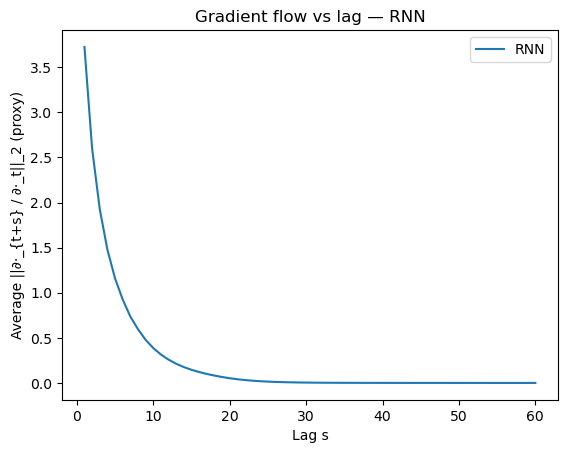

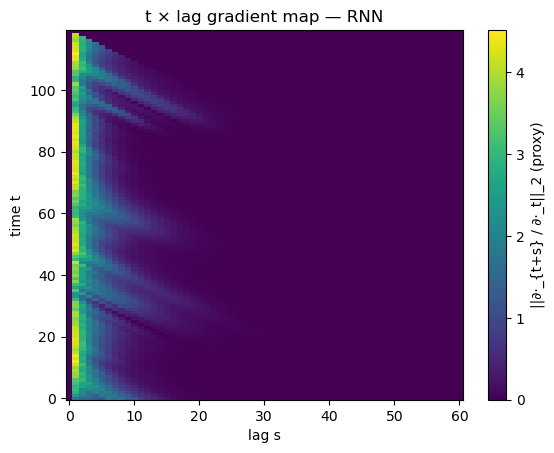

RNN: half-life 50% @ s=4, 10% @ s=11
<class 'torch.nn.modules.rnn.GRU'>
Word-level model params: 6304770
----------------------------------------------------------------------------------------------------


Epoch,Training Loss,Validation Loss,Auc
1,0.651400,0.568424,0.767426
2,0.524400,0.525290,0.809243
3,0.433300,0.518803,0.819857
4,0.377300,0.522908,0.823638
5,0.328200,0.567834,0.825676
6,0.278900,0.578672,0.826476
7,0.231000,0.632157,0.825271
8,0.202200,0.671057,0.822004
9,0.179400,0.725110,0.822391
10,0.149800,0.735397,0.821845


||∂h_{11}/∂h_{10}|| proxy: 1.1547346115112305


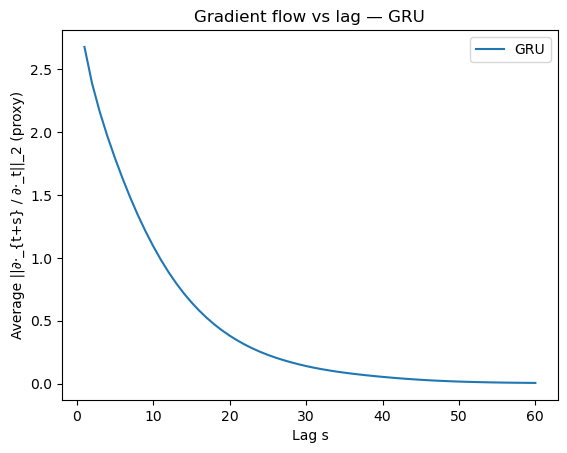

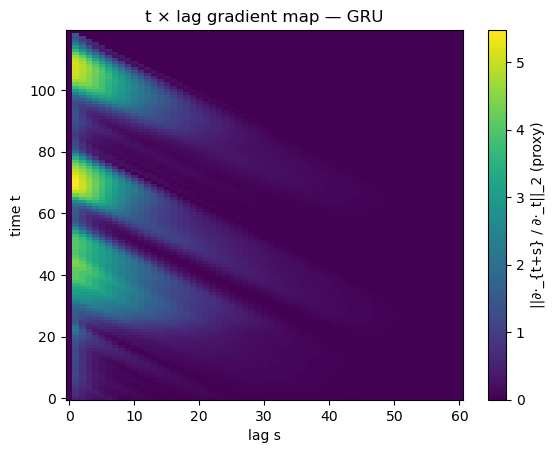

GRU: half-life 50% @ s=8, 10% @ s=24
<class 'torch.nn.modules.rnn.LSTM'>
Word-level model params: 6699522
----------------------------------------------------------------------------------------------------


Epoch,Training Loss,Validation Loss,Auc
1,0.663500,0.593311,0.746772
2,0.531800,0.517571,0.804204
3,0.432400,0.510457,0.827242
4,0.367200,0.500465,0.832584
5,0.307400,0.580244,0.832117
6,0.253700,0.579282,0.836705
7,0.208900,0.619628,0.838114
8,0.170300,0.663712,0.835249
9,0.158600,0.743369,0.834215
10,0.131000,0.738271,0.833648


||∂h_{t+1}/∂h_t|| proxy @ t=10: 0.511535108089447
||∂c_{t+1}/∂c_t|| proxy @ t=10: 2.0227198600769043


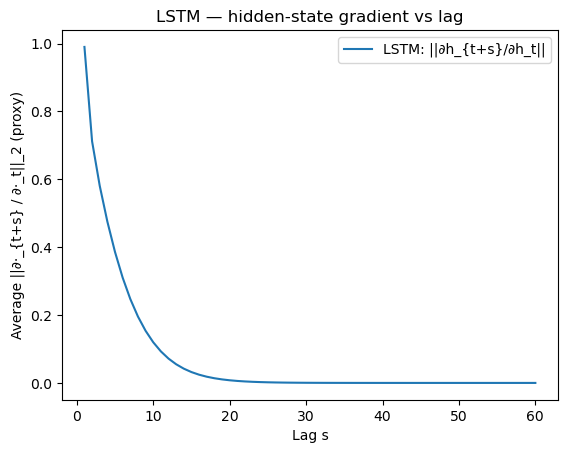

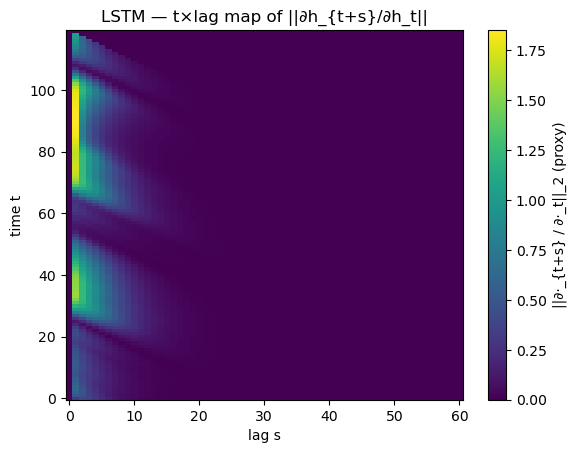

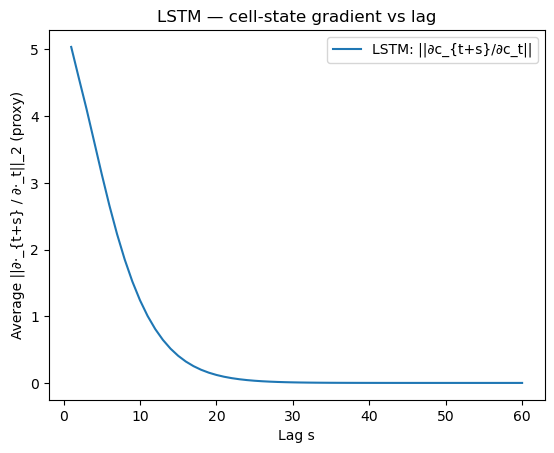

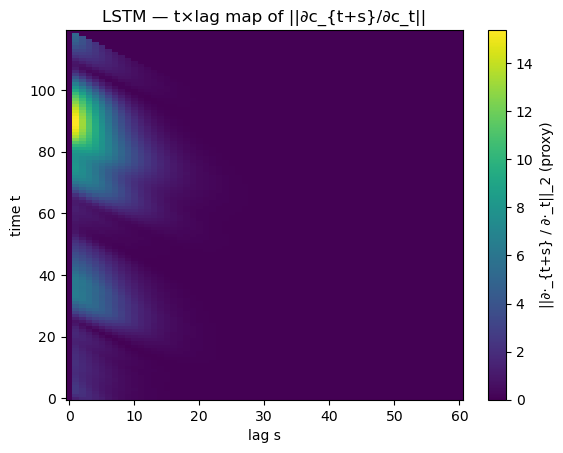

LSTM half-life (50%) — h: 4   c: 7
LSTM half-life (10%) — h: 11   c: 15

=== Gradient Flow Summary ===
model_name  num_params  best_auc grad_half_life_50pct_lag grad_half_life_10pct_lag                    curve_csv               curve_png               heat_png
       RNN     5515266  0.772414                     None                     None grad_viz/lstm_grad_curve.csv grad_viz/lstm_curve.png grad_viz/lstm_heat.png
       GRU     6304770  0.826476                     None                     None grad_viz/lstm_grad_curve.csv grad_viz/lstm_curve.png grad_viz/lstm_heat.png
      LSTM     6699522  0.838114                     None                     None grad_viz/lstm_grad_curve.csv grad_viz/lstm_curve.png grad_viz/lstm_heat.png

Saved per-model curves/plots under: grad_viz_lstm
Summary CSV: grad_viz_lstm/summary_grad_flow.csv


In [63]:
from torch.utils.data import DataLoader

BATCH_TRAIN = 64
BATCH_EVAL  = 64
EPOCHS = 10
LR = 2e-4

results = []
viz_dir = "grad_viz"
ensure_dir(viz_dir)

for rnn_type in [nn.RNN, nn.GRU, nn.LSTM]:
    # Build model
    word_model = UniversalRNNClassifier(
        vocab_size=vocab_size_word, pad_id=PAD_ID, rnn_type=rnn_type
    )

    # HF Trainer args
    word_args = TrainingArguments(
        output_dir=f"out_word_{rnn_type.__name__.lower()}",
        per_device_train_batch_size=BATCH_TRAIN,
        per_device_eval_batch_size=BATCH_EVAL,
        num_train_epochs=EPOCHS,
        learning_rate=LR,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_steps=50,
        report_to="none",
        load_best_model_at_end=True,
        metric_for_best_model="auc",
        greater_is_better=True,
        seed=42,
    )

    trainer_word = Trainer(
        model=word_model,
        args=word_args,
        train_dataset=train_word_ds,
        eval_dataset=val_word_ds,
        data_collator=word_collate,
        compute_metrics=compute_metrics,
    )

    print(rnn_type)
    print("Word-level model params:", count_params(word_model))
    print(100*'-')

    trainer_word.train()
    word_metrics = trainer_word.evaluate()
    best_auc = word_metrics.get("eval_auc", float("nan"))

    if rnn_type is nn.LSTM:
        viz_dir = "grad_viz_lstm"; os.makedirs(viz_dir, exist_ok=True)
    
        # Unroll with LSTMCell stack (weights copied) and grad-seeded initial states
        h_list, c_list = unroll_lstm_cells_with_grad_seed(word_model, T=120, device="cpu")
    
        # Quick sanity: s=1 should be > 0 for both paths
        print("||∂h_{t+1}/∂h_t|| proxy @ t=10:",
              torch.autograd.grad(0.5*(h_list[11]**2).sum(), h_list[10], retain_graph=True)[0].norm().item())
        print("||∂c_{t+1}/∂c_t|| proxy @ t=10:",
              torch.autograd.grad(0.5*(c_list[11]**2).sum(), c_list[10], retain_graph=True)[0].norm().item())
    
        # Curves & heatmaps for h and c
        l_h, n_h, H_h = jacobian_proxy_norms(h_list, max_lag=60)
        l_c, n_c, H_c = jacobian_proxy_norms(c_list, max_lag=60)
    
        pd.DataFrame({"lag": l_h.numpy(), "avg_grad_norm": n_h.numpy()}) \
            .to_csv(os.path.join(viz_dir, "lstm_h_grad_curve.csv"), index=False)
        pd.DataFrame({"lag": l_c.numpy(), "avg_grad_norm": n_c.numpy()}) \
            .to_csv(os.path.join(viz_dir, "lstm_c_grad_curve.csv"), index=False)
    
        plot_curve(l_h, n_h, "LSTM: ||∂h_{t+s}/∂h_t||",
                   out_path=os.path.join(viz_dir, "lstm_h_curve.png"),
                   title="LSTM — hidden-state gradient vs lag")
        plot_heatmap(H_h, out_path=os.path.join(viz_dir, "lstm_h_heat.png"),
                     title="LSTM — t×lag map of ||∂h_{t+s}/∂h_t||")
    
        plot_curve(l_c, n_c, "LSTM: ||∂c_{t+s}/∂c_t||",
                   out_path=os.path.join(viz_dir, "lstm_c_curve.png"),
                   title="LSTM — cell-state gradient vs lag")
        plot_heatmap(H_c, out_path=os.path.join(viz_dir, "lstm_c_heat.png"),
                     title="LSTM — t×lag map of ||∂c_{t+s}/∂c_t||")
    
        # Half-life stats
        print("LSTM half-life (50%) — h:", half_life(l_h, n_h, 0.5), "  c:", half_life(l_c, n_c, 0.5))
        print("LSTM half-life (10%) — h:", half_life(l_h, n_h, 0.1), "  c:", half_life(l_c, n_c, 0.1))

    else:
        viz_dir = "grad_viz"; os.makedirs(viz_dir, exist_ok=True)
        
        # Build cell stack & unroll with grad-seeded states
        h_list, kind = unroll_with_cells_and_seed_grad(word_model, T=120, device="cpu")
        
        # Sanity check: s=1 must be > 0
        phi = 0.5 * (h_list[10]**2).sum()
        #print("||∂h_{11}/∂h_{10}|| proxy:", torch.autograd.grad(phi, h_list[9], retain_graph=True)[0].norm().item())
        
        lags, norms, heat = jacobian_proxy_norms(h_list, max_lag=60)
        
        # Save & plot
        base = kind.lower()
        df_curve = pd.DataFrame({"lag": lags.numpy(), "avg_grad_norm": norms.numpy()})
        df_curve.to_csv(os.path.join(viz_dir, f"{base}_grad_curve.csv"), index=False)
        plot_curve(lags, norms, label=kind, out_path=os.path.join(viz_dir, f"{base}_curve.png"),
                   title=f"Gradient flow vs lag — {kind}")
        plot_heatmap(heat, out_path=os.path.join(viz_dir, f"{base}_heat.png"),
                     title=f"t × lag gradient map — {kind}")
        
        # Optional stats
        half50 = grad_half_life(lags, norms, 0.5)
        half10 = grad_half_life(lags, norms, 0.1)
        print(f"{kind}: half-life 50% @ s={half50}, 10% @ s={half10}")

    results.append({
        "model_name": rnn_type.__name__,
        "num_params": count_params(word_model),
        "best_auc": best_auc,
        "grad_half_life_50pct_lag": half_s,
        "grad_half_life_10pct_lag": tenth_s,
        "curve_csv": csv_path,
        "curve_png": curve_png,
        "heat_png": heat_png,
    })

# ---------- Summary table ----------
df_summary = pd.DataFrame(results)
summary_csv = os.path.join(viz_dir, "summary_grad_flow.csv")
df_summary.to_csv(summary_csv, index=False)

print("\n=== Gradient Flow Summary ===")
print(df_summary.to_string(index=False))
print(f"\nSaved per-model curves/plots under: {viz_dir}")
print(f"Summary CSV: {summary_csv}")

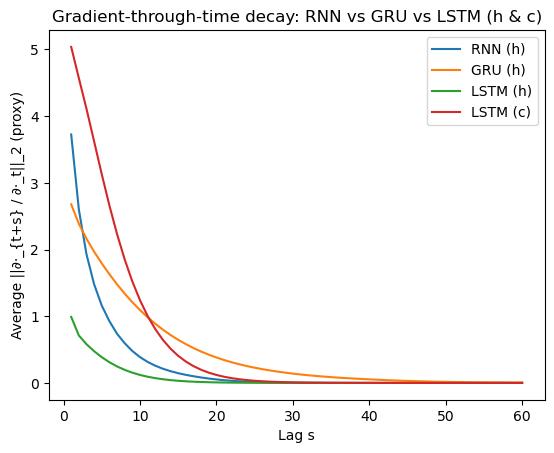

Combined plot saved to: grad_viz/combined_grad_curves.png

=== Gradient Half-Life Summary ===
curve_name  half_life_50pct_lag
   RNN (h)                    4
   GRU (h)                    8
  LSTM (h)                    4
  LSTM (c)                    7

Saved: grad_viz/grad_half_lives_summary.csv


In [65]:
def _safe_read(path):
    return pd.read_csv(path) if os.path.exists(path) else None

def _half_life_from_curve(df, frac=0.5):
    """
    df: columns ['lag', 'avg_grad_norm']
    returns smallest lag s where norm <= frac * norm_at_s1 ; None if never drops
    """
    if df is None or df.empty:
        return None
    # ensure sorted by lag
    df = df.sort_values('lag')
    # value at s=1
    base_row = df[df['lag'] == 1]
    if base_row.empty:
        base = df['avg_grad_norm'].iloc[0]
    else:
        base = float(base_row['avg_grad_norm'].iloc[0])
    if base == 0:
        return None
    thresh = frac * base
    below = df[df['avg_grad_norm'] <= thresh]
    if below.empty:
        return None
    return int(below['lag'].iloc[0])

def plot_combined_curves(curves, out_path):
    """
    curves: list of tuples (label, df) where df has ['lag','avg_grad_norm']
    """
    plt.figure()
    for label, df in curves:
        if df is None or df.empty: 
            continue
        df = df.sort_values('lag')
        plt.plot(df['lag'].values, df['avg_grad_norm'].values, label=label)
    plt.xlabel("Lag s")
    plt.ylabel("Average ||∂·_{t+s} / ∂·_t||_2 (proxy)")
    plt.title("Gradient-through-time decay: RNN vs GRU vs LSTM (h & c)")
    plt.legend()
    plt.savefig(out_path, bbox_inches="tight")
    plt.show()

def build_half_life_table(curve_map, out_csv):
    """
    curve_map: dict name->df
    Computes 50% and 10% half-lives for each available curve and saves a table.
    """
    rows = []
    for name, df in curve_map.items():
        if df is None or df.empty:
            continue
        hl50 = _half_life_from_curve(df, 0.5)
        hl10 = _half_life_from_curve(df, 0.1)
        rows.append({
            "curve_name": name,
            "half_life_50pct_lag": hl50,
        })
    table = pd.DataFrame(rows)
    os.makedirs(os.path.dirname(out_csv), exist_ok=True)
    table.to_csv(out_csv, index=False)
    print("\n=== Gradient Half-Life Summary ===")
    if not table.empty:
        print(table.to_string(index=False))
    else:
        print("(no curves found)")
    print(f"\nSaved: {out_csv}")
    return table

# ---- expected file layout (adjust paths if you changed them) ----
base_dir = "grad_viz"
lstm_dir = "grad_viz_lstm"  # where LSTM h/c probe saved

paths = {
    # single-head curves from the general probe
    "RNN (h)":  os.path.join(base_dir, "rnn_grad_curve.csv"),
    "GRU (h)":  os.path.join(base_dir, "gru_grad_curve.csv"),
    "LSTM (h)": os.path.join(base_dir, "lstm_grad_curve.csv"),  # if you saved LSTM-h here
    # explicit LSTM h/c curves (preferred if you used the dedicated LSTM probe)
    "LSTM (h) [cells]": os.path.join(lstm_dir, "lstm_h_grad_curve.csv"),
    "LSTM (c) [cells]": os.path.join(lstm_dir, "lstm_c_grad_curve.csv"),
}

# prefer the dedicated LSTM cell-based h curve if present
lstm_h_cells = _safe_read(paths["LSTM (h) [cells]"])
lstm_c_cells = _safe_read(paths["LSTM (c) [cells]"])
lstm_h_general = _safe_read(paths["LSTM (h)"])

curve_map = {
    "RNN (h)": _safe_read(paths["RNN (h)"]),
    "GRU (h)": _safe_read(paths["GRU (h)"]),
    # pick LSTM h from cells if available, else general
    "LSTM (h)": lstm_h_cells if lstm_h_cells is not None else lstm_h_general,
    "LSTM (c)": lstm_c_cells,  # may be None if you didn’t run the LSTM c probe
}

# Filter out missing curves and set plotting list in the desired order
plot_list = [(name, df) for name, df in [
    ("RNN (h)", curve_map["RNN (h)"]),
    ("GRU (h)", curve_map["GRU (h)"]),
    ("LSTM (h)", curve_map["LSTM (h)"]),
    ("LSTM (c)", curve_map["LSTM (c)"]),
] if df is not None]

# Make combined plot
combined_png = os.path.join(base_dir, "combined_grad_curves.png")
plot_combined_curves(plot_list, combined_png)
print(f"Combined plot saved to: {combined_png}")

# Build & save half-life table
summary_csv = os.path.join(base_dir, "grad_half_lives_summary.csv")
_ = build_half_life_table(curve_map, summary_csv)

<a id='ner'></a>
# Sequence labeling. NER task

## Problem Statement

Let the input be a sequence of tokens:

$$
X = \left( x_1, x_2, \ldots, x_T \right)
$$

where each $x_t$ represents an individual token (e.g., a word in a sentence) and $T$ is the sequence length.

The objective of sequence labeling is to assign a corresponding label sequence:

$$
Y = \left( y_1, y_2, \ldots, y_T \right)
$$

where each $y_t$ is selected from a finite set of labels $\mathcal{L}$.

The mapping function is defined as:

$$
f: X \rightarrow Y
$$

Often, the task is formulated in a probabilistic framework. For a given model parameterized by $\theta$, we define the conditional probability of a label sequence $Y$ given $X$ as:

$$
P(Y \mid X; \theta)
$$

Training the model on a dataset $\{(X^{(i)}, Y^{(i)})\}_{i=1}^{N}$ typically involves maximizing the likelihood:

$$
\mathcal{L}(\theta) = \prod_{i=1}^{N} P\left(Y^{(i)} \mid X^{(i)}; \theta\right)
$$

or equivalently the log-likelihood:

$$
\log \mathcal{L}(\theta) = \sum_{i=1}^{N} \log P\left(Y^{(i)} \mid X^{(i)}; \theta\right)
$$

This formalism underlies many sequence labeling tasks such as part-of-speech tagging or named entity recognition.


## Named Entity Recognition (NER) as a Sequence Labeling Task

Named Entity Recognition is a classic example of a sequence labeling task where the goal is to identify and classify named entities (such as persons, organizations, locations, etc.) within a sentence.

### Example

Consider the sentence:

> "Barack Obama was born in Hawaii."

We first represent the sentence as a sequence of tokens:

$$
X = [\text{Barack},\ \text{Obama},\ \text{was},\ \text{born},\ \text{in},\ \text{Hawaii},\ \text{.}]
$$

Using a common BIO tagging scheme, we assign labels to each token:

- **B-PER**: Beginning of a person name  
- **I-PER**: Inside of a person name  
- **B-LOC**: Beginning of a location name  
- **O**: Outside any named entity  

The corresponding label sequence might be:

$$
Y = [\text{B-PER},\ \text{I-PER},\ \text{O},\ \text{O},\ \text{O},\ \text{B-LOC},\ \text{O}]
$$

Thus, the mapping function for NER assigns:

$$
\text{f(“Barack”)} \rightarrow \text{B-PER}, \quad \text{f(“Obama”)} \rightarrow \text{I-PER}, \quad \text{f(“Hawaii”)} \rightarrow \text{B-LOC}
$$

while non-entity words receive the label $\text{O}$.

> **TODO**: Read about different tagging schemes e.g. BIO, IO, BILOU

## Evaluation: F1 modifications

### 1) Entity-level (span) scoring
- **Unit:** whole entities (span + type). An entity is correct **only if** both **boundaries and label** match the gold entity.
- **Pros:** reflects downstream use; discourages “almost-right” spans; is the **standard** CoNLL-style metric.
- **Cons:** no partial credit; early models with boundary issues get low F1 and are harder to debug with a single number.
- For richer diagnostics (strict vs. partial vs. type-only), tools like **nervaluate** help.

### 2) Token-level scoring
- **Unit:** per-token tags (e.g., BIO). Simple and useful for debugging which tokens are wrong.
- **Pros:** smooth learning curves, often higher scores, great for **error analysis**.
- **Cons:** can **overstate** quality for multi-token entities (e.g., getting `New` right but not `York City`). Many projects therefore **report entity-F1** for final results and keep token-F1 as a diagnostic.

### 3) Character-level / partial-match scoring
- **Unit:** overlapping characters (or subspans), optionally type-aware. Gives **graded credit** for near-misses and handles tokenization edge cases.
- **Pros:** fairer for hyphenation/subwords; helps separate **boundary** vs. **type** mistakes.
- **Cons:** not standardized; choices about overlap and weighting change results → less comparable across papers. Use alongside strict entity-F1 for analysis.

## Data preparation

### uk_geo_dataset
Ukrainian dataset [Corpora Ukrainian](https://huggingface.co/datasets/ukr-models/Ukr-Synth).
It contains approximately 1M text samples with location and organization entities.

In [2]:
from huggingface_hub import snapshot_download

repo = "ukr-models/Ukr-Synth"
local_dir = "./ukr-data-ner"

# Download the model to the specified directory
snapshot_download(
    repo_type='dataset',
    repo_id=repo,
    local_dir=local_dir,
    allow_patterns=["*"]  # Adjust to download specific files if needed
)

print(f"Downloaded to {local_dir}")

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Downloaded to ./ukr-data-ner


In [3]:
import gzip
from tqdm.autonotebook import tqdm

def read_conll_file(filepath, nrows=10):
    sentences = []
    current_sentence = []
    sentence_counts = 0
    with gzip.open(filepath, 'rt', encoding='utf-8') as file:
        for line in file:
            line = line.strip()
            # A blank line indicates the end of a sentence
            if not line:
                if current_sentence:
                    sentences.append(current_sentence)
                    sentence_counts += 1
                    current_sentence = []
            else:
                # Split the line into its fields (e.g., token, POS, label, etc.)
                parts = line.split()
                current_sentence.append(parts)
            if sentence_counts >= nrows:
                break
        # If the file doesn't end with a newline, add the last sentence.
        if current_sentence:
            sentences.append(current_sentence)
            
    return sentences

# Example usage:
train_filepath = "./ukr-data-ner/data/train.conllu.gz"
valid_filepath = "./ukr-data-ner/data/dev.conllu.gz"
train_data = read_conll_file(train_filepath, nrows=200_000)
valid_data = read_conll_file(valid_filepath, nrows=10_000)
print("Number of train sentences:", len(train_data))
print("Number of valid sentences:", len(valid_data))
print("Sentence example:", train_data[1])

Number of train sentences: 200000
Number of valid sentences: 10000
Sentence example: [['#', 'sent_id', '=', '1'], ['#', 'text', '=', 'А', 'поки', 'що', 'починали', 'цвісти', 'троянди,', 'випускники', 'складали', 'іспити,', 'учні', 'відпочивали', 'в', 'пришкільному', 'таборі,', 'а', 'директор', 'Володимир', 'Хоботов', 'марно', 'оббивав', 'пороги', 'в', 'пошуках', 'транспорту.'], ['1', 'А', '_', 'CCONJ', 'CCONJ', 'SpaceAfter=Yes', '4', 'cc', '_', 'O'], ['2', 'поки', '_', 'ADV', 'ADV', 'PronType=Rel|SpaceAfter=Yes', '4', 'advmod', '_', 'O'], ['3', 'що', '_', 'PART', 'PART', 'SpaceAfter=Yes', '2', 'discourse', '_', 'O'], ['4', 'починали', '_', 'VERB', 'VERB', 'Aspect=Imp|Mood=Ind|Number=Plur|Tense=Past|VerbForm=Fin|SpaceAfter=Yes', '0', 'root', '_', 'O'], ['5', 'цвісти', '_', 'VERB', 'VERB', 'Aspect=Imp|VerbForm=Inf|SpaceAfter=Yes', '4', 'xcomp', '_', 'O'], ['6', 'троянди', '_', 'NOUN', 'NOUN', 'Animacy=Inan|Case=Nom|Gender=Masc|Number=Plur|SpaceAfter=No', '4', 'nsubj', '_', 'O'], ['7', ',

In [4]:
import pandas as pd

columns = ['ID', 'FORM', 'LEMMA', 'UPOS', 'XPOS', 'FEATS', 'HEAD', 'DEPREL', 'DEPS', 'MISC']

sentence = pd.DataFrame(train_data[1][2:], columns=columns)
sentence

,ID,FORM,LEMMA,UPOS,XPOS,FEATS,HEAD,DEPREL,DEPS,MISC
0,1,А,_,CCONJ,CCONJ,SpaceAfter=Yes,4,cc,_,O
1,2,поки,_,ADV,ADV,PronType=Rel|SpaceAfter=Yes,4,advmod,_,O
2,3,що,_,PART,PART,SpaceAfter=Yes,2,discourse,_,O
3,4,починали,_,VERB,VERB,Aspect=Imp|Mood=Ind|Number=Plur|Tense=Past|Ver...,0,root,_,O
4,5,цвісти,_,VERB,VERB,Aspect=Imp|VerbForm=Inf|SpaceAfter=Yes,4,xcomp,_,O
5,6,троянди,_,NOUN,NOUN,Animacy=Inan|Case=Nom|Gender=Masc|Number=Plur|...,4,nsubj,_,O
6,7,",",_,PUNCT,PUNCT,SpaceAfter=Yes,9,punct,_,O
7,8,випускники,_,NOUN,NOUN,Animacy=Anim|Case=Nom|Gender=Masc|Number=Plur|...,9,nsubj,_,O
8,9,складали,_,VERB,VERB,Aspect=Imp|Mood=Ind|Number=Plur|Tense=Past|Ver...,4,parataxis,_,O
9,10,іспити,_,NOUN,NOUN,Animacy=Inan|Case=Acc|Gender=Masc|Number=Plur|...,9,obj,_,O


# CoNLL-U Format Explained

A file in the CoNLL-U format is typically structured with two types of lines: **comment lines** and **token lines**.

---

## 1. Comment Lines

- **Comment lines** start with the `#` character.
- They provide metadata about the sentence.
  - **Example 1:**  
    ```plaintext
    # sent_id = 1
    ```  
    This line indicates the sentence identifier.
  
  - **Example 2:**  
    ```plaintext
    # text = А поки що починали цвісти троянди, випускники складали іспити, учні відпочивали в пришкільному таборі, а директор Володимир Хоботов марно оббивав пороги в пошуках транспорту.
    ```  
    This line shows the full text of the sentence.

---

## 2. Token Lines

After the comment lines, each subsequent line (until a blank line) represents one token in the sentence. Each token line contains **10 columns** separated by whitespace (or tabs). Here’s the breakdown:

1. **ID**  
   - Token index (starting at 1).  
   - *Example:* `1`

2. **FORM**  
   - The actual word or punctuation as it appears in the sentence.  
   - *Example:* `А`

3. **LEMMA**  
   - The lemma or base form of the token.  
   - *Example:* `_` (underscore means it is not provided)

4. **UPOS**  
   - Universal part-of-speech tag (e.g., `NOUN`, `VERB`, `CCONJ`).  
   - *Example:* `CCONJ`

5. **XPOS**  
   - Language-specific part-of-speech tag.  
   - *Example:* `CCONJ`

6. **FEATS**  
   - Morphological features (e.g., tense, number, case) in a pipe-separated format.  
   - *Example:* `SpaceAfter=Yes`

7. **HEAD**  
   - The index of the syntactic head (governor of the current token in the dependency tree).  
   - *Example:* `4`

8. **DEPREL**  
   - Dependency relation to the head (e.g., `nsubj`, `obj`, `cc`).  
   - *Example:* `cc`
   - In the sentence "The big lion hunts the gazelles," the dependency relations show that "hunts" is the head verb, "lion" is the subject ("nsubj"), and "gazelles" is the object ("obj"). "The" is a determiner ("det") for "lion," and "big" is an adjectival modifier ("amod") of "lion". 

9. **DEPS**  
   - Enhanced dependency graph representation; often `_` if not used.  
   - *Example:* `_`

10. **MISC**  
    - Miscellaneous information (could include space handling, named entity tags, etc.).  
    - *Example:* `O`

> **TODO**: Read format docs https://universaldependencies.org/docs/format.html

In [21]:
import collections

def get_label_distribution(sentences, label_index=9):
    label_counter = collections.Counter()
    for sentence in sentences:
        for token in sentence:
            if token[0].startswith('#') or len(token) != 10:
                continue
            label = token[label_index]
            label_counter[label] += 1
    return label_counter

label_dist = get_label_distribution(train_data)

print("Unique labels:")
print(list(label_dist.keys()))

print("\nLabel distribution:")
for label, count in label_dist.items():
    print(f"{label}: {count}")

Unique labels:
['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']

Label distribution:
O: 3256383
B-PER: 57101
I-PER: 30937
B-ORG: 53905
I-ORG: 48344
B-LOC: 67384
I-LOC: 15892


In [22]:
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator

In [23]:
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator


def yield_tokens(data):
    for sentence in data:
        tokens = [row[1] for row in sentence if not row[0].startswith('#')]
        yield tokens

# Build the vocabulary using torchtext's utility
vocab = build_vocab_from_iterator(yield_tokens(train_data + valid_data), specials=["<unk>", "<pad>"])
vocab.set_default_index(vocab["<unk>"])

# Define a tokenizer that extracts tokens from a given sentence (ignoring metadata rows)
def simple_tokenizer(sentence):
    return [row[1] for row in sentence if not row[0].startswith('#')]

# Example usage:
tokens = simple_tokenizer(train_data[1])
token_indices = [vocab[token] for token in tokens]

print("Tokens:", tokens)
print("Token indices:", token_indices)

Tokens: ['А', 'поки', 'що', 'починали', 'цвісти', 'троянди', ',', 'випускники', 'складали', 'іспити', ',', 'учні', 'відпочивали', 'в', 'пришкільному', 'таборі', ',', 'а', 'директор', 'Володимир', 'Хоботов', 'марно', 'оббивав', 'пороги', 'в', 'пошуках', 'транспорту', '.']
Token indices: [62, 241, 11, 14934, 44930, 22755, 2, 13262, 20319, 13131, 2, 4773, 19783, 6, 211139, 8882, 2, 24, 737, 243, 160236, 11513, 73106, 59650, 6, 7276, 1131, 3]


In [24]:
len(vocab)

232984

In [25]:
vocab.lookup_indices(["поки", "що", "покищо", "покищо#", "<unk>", "<pad>"])

[241, 11, 103135, 0, 0, 1]

In [26]:
token_freqs = collections.Counter(token for tokens in yield_tokens(train_data) for token in tokens)

# Get the 30 most common tokens
top30 = token_freqs.most_common(30)
top30

[(',', 241468),
 ('.', 197222),
 ('"', 56487),
 ('на', 55117),
 ('в', 46747),
 ('і', 42945),
 ('у', 42879),
 ('-', 40398),
 ('з', 38501),
 ('що', 34549),
 ('не', 31999),
 ('та', 27169),
 ('до', 24115),
 ('за', 19184),
 ('«', 15318),
 ('»', 14810),
 ('–', 13675),
 ('про', 12716),
 ('це', 12170),
 ('У', 11854),
 ('для', 11686),
 ('від', 10870),
 ('а', 9884),
 ('як', 9037),
 (':', 8449),
 ('України', 8296),
 ('із', 8124),
 ('які', 8054),
 ('його', 7867),
 ('(', 7866)]

In [27]:
import torch

class TextDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        conll_data,
        dataset_vocab,
        labels_names,
        max_length
    ):
        self.conll_data = conll_data
        self.vocab = dataset_vocab
        self.pad_token_id = self.vocab['<pad>']
        self.max_length = int(max_length)
        self.labels_names = labels_names
        self.label2id = {k: ind for ind, k in enumerate(list(self.labels_names))}
        self.id2label = {v: k for k, v in self.label2id.items()}

    def simple_tokenizer(self, sentence):
        return [row[1] for row in sentence if not row[0].startswith('#')]

    def get_labels(self, sentence):
        return [self.label2id[row[-1]] for row in sentence if not row[0].startswith('#')]
                
    def __getitem__(self, idx):
        current_item = self.conll_data[idx]
        input_ids = self.vocab(self.simple_tokenizer(current_item))
        labels = self.get_labels(current_item)
        return {
            'input_ids': input_ids[:self.max_length],
            'labels': labels[:self.max_length]
        }
    
    def __len__(self):
        return len(self.conll_data)

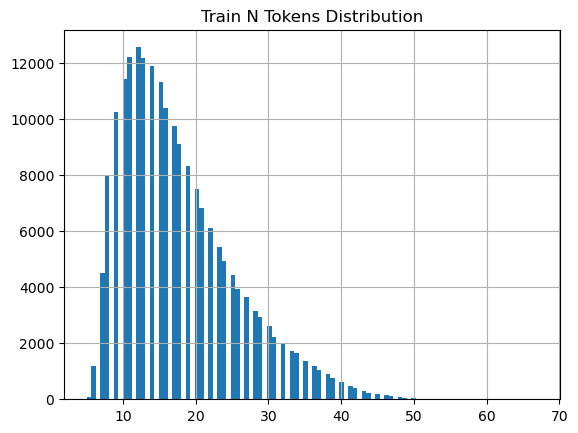

0.99 Quantile of N tokens: 41.0


In [28]:
from matplotlib import pyplot as plt
import numpy as np

# Here we want to figure out empirically max_length

train_n_tokens = pd.Series([len(simple_tokenizer(s)) for s in train_data])

plt.title("Train N Tokens Distribution")
train_n_tokens.hist(bins=100)
plt.show()

q99 = np.quantile(train_n_tokens, 0.99)
print(f"0.99 Quantile of N tokens: {q99}")

In [29]:
ds_train = TextDataset(train_data, vocab, list(label_dist.keys()), q99)
ds_valid = TextDataset(valid_data, vocab, list(label_dist.keys()), q99)

In [38]:
class DataCollatorForTokenClassification:
    def __init__(self, pad_token_id, label_pad_token_id=-100):
        self.pad_token_id = pad_token_id
        self.label_pad_token_id = label_pad_token_id #-100 to ignore tokens in loss computations

    def __call__(self, features):
        # Extract input_ids and labels from the list of feature dictionaries.
        input_ids_list = [f["input_ids"] for f in features]
        labels_list = [f["labels"] for f in features]
        
        # Determine the maximum sequence length in this batch.
        batch_max_length = max(len(ids) for ids in input_ids_list)
        
        # Pad input_ids and labels on the right.
        padded_input_ids = [
            ids + [self.pad_token_id] * (batch_max_length - len(ids))
            for ids in input_ids_list
        ]
        padded_labels = [
            labels + [self.label_pad_token_id] * (batch_max_length - len(labels))
            for labels in labels_list
        ]
        
        # Convert lists to tensors.
        batch_input_ids = torch.tensor(padded_input_ids, dtype=torch.long)
        batch_labels = torch.tensor(padded_labels, dtype=torch.long)
        
        return {"input_ids": batch_input_ids, "labels": batch_labels}

In [31]:
from torch.utils.data import DataLoader

pad_token_id = ds_train.vocab['<pad>']
collator = DataCollatorForTokenClassification(pad_token_id, label_pad_token_id=-100)

dataloader = DataLoader(
    ds_train,
    batch_size=64,
    collate_fn=collator
)

In [32]:
data_iter = iter(dataloader)
first_batch = next(data_iter)
first_batch

{'input_ids': tensor([[ 3472,  4841,   140,  ...,     1,     1,     1],
         [   62,   241,    11,  ...,     1,     1,     1],
         [  223,    58,     2,  ...,     1,     1,     1],
         ...,
         [  185,    54,  8533,  ...,     1,     1,     1],
         [66451,     8,   129,  ...,     1,     1,     1],
         [   62,  4605,  4087,  ...,     1,     1,     1]]),
 'labels': tensor([[   0,    0,    0,  ..., -100, -100, -100],
         [   0,    0,    0,  ..., -100, -100, -100],
         [   0,    0,    0,  ..., -100, -100, -100],
         ...,
         [   0,    0,    0,  ..., -100, -100, -100],
         [   0,    0,    0,  ..., -100, -100, -100],
         [   0,    0,    0,  ..., -100, -100, -100]])}

In [33]:
import os
import torch
import torch.nn as nn
from dataclasses import dataclass
from typing import Optional, Dict, Any, List

import evaluate
import numpy as np

from transformers import (
    Trainer, TrainingArguments
)
from transformers.modeling_outputs import TokenClassifierOutput


metric = evaluate.load("seqeval")  # pip install seqeval
label_names = ds_train.labels_names
id2label = ds_train.id2label
label2id = {v: k for k, v in id2label.items()}

def compute_metrics_fn(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    true_labels = [
        [id2label[l] for l in label_row if l != -100]
        for label_row in labels
    ]
    true_preds = []
    for pred_row, label_row in zip(preds, labels):
        row = []
        for p, l in zip(pred_row, label_row):
            if l != -100:
                row.append(id2label[int(p)])
        true_preds.append(row)

    results = metric.compute(predictions=true_preds, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

In [34]:
class UniversalRNNTokenClassifier(nn.Module):
    def __init__(
        self,
        num_embeddings: int,
        num_labels: int,
        embed_dim: int = 256,
        rnn_hidden: int = 512,
        rnn_type: nn.Module = nn.GRU,   # nn.RNN / nn.GRU / nn.LSTM
        n_rnns: int = 3,
        bidirectional: bool = True,
        dropout_rate: float = 0.3,
        pad_id: int = 0,
        average_type: Optional[str] = None,  # kept for API symmetry; unused here
    ):
        super().__init__()
        self.num_labels = num_labels
        self.pad_id = pad_id
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1
        self.rnn_type = rnn_type
        self.hidden_size = rnn_hidden

        self.embed = nn.Embedding(num_embeddings, embed_dim, padding_idx=pad_id)
        self.dropout = nn.Dropout(dropout_rate)

        self.rnn = rnn_type(
            input_size=embed_dim,
            hidden_size=rnn_hidden,
            num_layers=n_rnns,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout_rate if n_rnns > 1 else 0.0,
        )
        self.classifier = nn.Linear(rnn_hidden * self.num_directions, num_labels)

        self.loss_fn = nn.CrossEntropyLoss(ignore_index=-100)

    def forward(
        self,
        input_ids: torch.LongTensor = None,
        labels: Optional[torch.LongTensor] = None,
        attention_mask: Optional[torch.LongTensor] = None,  # not used by RNN; masking is via labels=-100
        **kwargs
    ):
        # input_ids: [B, T]
        x = self.embed(input_ids)                  # [B, T, E]
        x = self.dropout(x)

        # You can pack based on attention_mask or true lengths if you like.
        # For simplicity (and because labels carry -100), we run unpacked:
        out, _ = self.rnn(x)                       # [B, T, H*D]
        out = self.dropout(out)
        logits = self.classifier(out)              # [B, T, C]

        loss = None
        if labels is not None:
            # CrossEntropy over time; ignore_index handles padding.
            loss = self.loss_fn(logits.view(-1, self.num_labels), labels.view(-1))

        # Return the standard HF TokenClassifierOutput so Trainer can read loss/logits.
        return TokenClassifierOutput(loss=loss, logits=logits)

In [39]:
data_collator = DataCollatorForTokenClassification(pad_token_id, label_pad_token_id=-100)


NUM_EMBEDDINGS = len(ds_train.vocab)   
NUM_LABELS     = len(ds_train.labels_names)

model = UniversalRNNTokenClassifier(
    num_embeddings=NUM_EMBEDDINGS,
    num_labels=NUM_LABELS,
    embed_dim=256,
    rnn_hidden=512,
    rnn_type=nn.GRU,           # nn.LSTM or nn.RNN if needed
    n_rnns=3,
    bidirectional=True,
    dropout_rate=0.3,
    pad_id=0,
)

In [41]:
from pytorch_lightning.loggers import WandbLogger
import wandb

wandb.init(
    project="nlp-ner-lecture",
    entity="bazdyrev99-igor-sikorsky-kyiv-polytechnic-institute", 
    name='gru-bidirectional-3layers'
)

wandb_logger = WandbLogger(log_model=True)

wandb: Currently logged in as: bazdyrev99 (bazdyrev99-igor-sikorsky-kyiv-polytechnic-institute) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [42]:
LEARNING_RATE = 1e-3
BATCH_SIZE    = 64
TOTAL_EPOCHS  = 5

training_args = TrainingArguments(
    output_dir="./hf_checkpoints_gru_bi3",
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    num_train_epochs=TOTAL_EPOCHS,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",       # "f1" from compute_metrics
    greater_is_better=True,
    report_to=["wandb"],              # enable W&B
    run_name="gru-bidirectional-3layers",
    gradient_accumulation_steps=1,
    gradient_checkpointing=False
)

In [43]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds_train,
    eval_dataset=ds_valid,
    data_collator=data_collator,
    compute_metrics=compute_metrics_fn,
)

trainer.train()
eval_metrics = trainer.evaluate()
print("Eval:", eval_metrics)

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.138000,0.107906,0.751698,0.621943,0.680692,0.968031
2,0.094100,0.090256,0.736015,0.711610,0.723607,0.971877
3,0.080200,0.080003,0.758994,0.734413,0.746501,0.975175
4,0.061200,0.076001,0.768390,0.751377,0.759788,0.976908
5,0.052800,0.075107,0.776155,0.760850,0.768426,0.977174


Eval: {'eval_loss': 0.07510659843683243, 'eval_precision': 0.7761546241150691, 'eval_recall': 0.7608504075787619, 'eval_f1': 0.7684263225232242, 'eval_accuracy': 0.9771739007668937, 'eval_runtime': 2.9995, 'eval_samples_per_second': 3333.937, 'eval_steps_per_second': 52.343, 'epoch': 5.0}


In [49]:
from nltk import word_tokenize

def merge_bio_entities(tokens, bio_tags):
    entities, cur = [], None
    for tok, tag in zip(tokens, bio_tags):
        if tag.startswith("B-"):
            if cur: entities.append(cur)
            cur = {"text": tok, "label": tag[2:]}
        elif tag.startswith("I-") and cur and cur["label"] == tag[2:]:
            cur["text"] += " " + tok
        else:  # "O" or mismatched I-
            if cur: entities.append(cur); cur = None
    if cur: entities.append(cur)
    return entities

def _infer(self, text, vocab, id2label, tokenizer=None):
    device = next(self.parameters()).device
    tok = (tokenizer or word_tokenize)(text)
    ids = vocab(tok)                       # expects: vocab(List[str]) -> List[int]
    inp = torch.tensor([ids], dtype=torch.long, device=device)  # [1, T]

    self.eval()
    with torch.no_grad():
        out = self(input_ids=inp)          # TokenClassifierOutput
        logits = out.logits                # [1, T, C]
        pred_ids = logits.argmax(dim=-1).squeeze(0).tolist()

    bio_tags = [id2label[p] for p in pred_ids]
    return merge_bio_entities(tok, bio_tags)


best_model = trainer.model.eval()

# attach method to the model class or just to this instance
import types
best_model.infer = types.MethodType(_infer, best_model)

In [56]:
best_model.infer('Привіт, як у тебе справи?', vocab, id2label)

[]

In [57]:
text = """Палата відділення щелепнолицевої хірургії по вулиці Зоологічній, 
в палаті на кроватях лежать Василь Гнатович і Енгельс Гасанович"""
best_model.infer(text, vocab, id2label)

[{'text': 'вулиці Зоологічній', 'label': 'LOC'},
 {'text': 'Василь Гнатович', 'label': 'PER'},
 {'text': 'Енгельс Гасанович', 'label': 'PER'}]

In [58]:
vocab['Зоологічній'], vocab['Василь'], vocab['Гнатович'], vocab['Енгельс'], vocab['Гасанович']

(135756, 1334, 0, 133689, 0)

In [59]:
text = """Недалеко от Богуслава, коло Росі, в довгому покрученому яру розкинулось село Семигори. 
Яр в'ється гадюкою між крутими горами, між зеленими терасами; 
од яру на всі боки розбіглись, неначе гілки дерева, глибокі рукави й поховались десь далеко в густих лісах."""
best_model.infer(text, vocab, id2label)

[{'text': 'Семигори', 'label': 'LOC'}]